In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from google.colab import files


In [ ]:
uploaded = files.upload()

df = pd.read_excel(next(iter(uploaded)))

print(df.head())


Saving Dataset.xlsx to Dataset (1).xlsx
   Year  January  February  March  April   May  June  July  August  September  \
0  2021     4207      4000   4431   4395  4249  4157  4918    4569       4811   
1  2022     3097      2771   3981   4717  5291  4987  4949    5144       5285   
2  2023     5396      4690   5798   6163  6054  6001  6103    6089       6201   
3  2024     5989      5241   6478   6724  6097  6063  6392    6856       6722   
4  2025     6332      5811   7290   6674  6808  7318  6851    7598       8117   

   October  November  December      Type  
0     4177      3887      3710  Injuries  
1     5686      5021      5062  Injuries  
2     6723      6156      5642  Injuries  
3     7155      6245      6400  Injuries  
4     8245      7162      6347  Injuries  


In [ ]:

months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

long_df = df.melt(
    id_vars=["Year", "Type"],
    value_vars=months,
    var_name="Month",
    value_name="Value"
)

long_df["Date"] = pd.to_datetime(
    long_df["Year"].astype(str) + "-" +
    long_df["Month"] + "-01"
)

long_df = long_df.sort_values(["Type", "Date"])

print(long_df.head(15))

     Year   Type      Month  Value       Date
5    2021  Death    January    468 2021-01-01
15   2021  Death   February    485 2021-02-01
25   2021  Death      March    565 2021-03-01
35   2021  Death      April    613 2021-04-01
45   2021  Death        May    680 2021-05-01
55   2021  Death       June    626 2021-06-01
65   2021  Death       July    674 2021-07-01
75   2021  Death     August    668 2021-08-01
85   2021  Death  September    652 2021-09-01
95   2021  Death    October    629 2021-10-01
105  2021  Death   November    604 2021-11-01
115  2021  Death   December    662 2021-12-01
6    2022  Death    January    571 2022-01-01
16   2022  Death   February    466 2022-02-01
26   2022  Death      March    596 2022-03-01


In [ ]:
train = long_df[
    (long_df["Type"] == "Injuries") &
    (long_df["Date"] < "2025-01-01")
].copy()

train = train.set_index("Date")["Value"]

model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = model.fit(disp=False)

forecast_injuries = fit.forecast(steps=12)

print("2025 Injuries Forecast")
print(forecast_injuries.round(0))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


2025 Injuries Forecast
2025-01-01    6580.0
2025-02-01    5861.0
2025-03-01    7045.0
2025-04-01    7336.0
2025-05-01    6899.0
2025-06-01    6843.0
2025-07-01    7113.0
2025-08-01    7444.0
2025-09-01    7386.0
2025-10-01    7810.0
2025-11-01    6999.0
2025-12-01    7003.0
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:

forecasts = {}

for data_type in ["Injuries", "Death"]:

    train = long_df[
        (long_df["Type"] == data_type) &
        (long_df["Date"] < "2025-01-01")
    ].copy()

    train = train.set_index("Date")["Value"]

    model = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    forecasts[data_type] = fit.forecast(steps=12)

    print(f"\n2025 {data_type} Forecast")
    print(forecasts[data_type].round(0))


# Store forecasts separately
forecast_injuries = forecasts["Injuries"]
forecast_death = forecasts["Death"]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



2025 Injuries Forecast
2025-01-01    6580.0
2025-02-01    5861.0
2025-03-01    7045.0
2025-04-01    7336.0
2025-05-01    6899.0
2025-06-01    6843.0
2025-07-01    7113.0
2025-08-01    7444.0
2025-09-01    7386.0
2025-10-01    7810.0
2025-11-01    6999.0
2025-12-01    7003.0
Freq: MS, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



2025 Death Forecast
2025-01-01    386.0
2025-02-01    355.0
2025-03-01    401.0
2025-04-01    443.0
2025-05-01    337.0
2025-06-01    372.0
2025-07-01    365.0
2025-08-01    365.0
2025-09-01    333.0
2025-10-01    345.0
2025-11-01    292.0
2025-12-01    321.0
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
actual_2025 = long_df[
    long_df["Year"] == 2025
].copy()

actual_2025 = actual_2025.pivot(
    index="Date",
    columns="Type",
    values="Value"
)

print(actual_2025)

Type        Death  Injuries
Date                       
2025-01-01    407      6332
2025-02-01    423      5811
2025-03-01    583      7290
2025-04-01    502      6674
2025-05-01    466      6808
2025-06-01    483      7318
2025-07-01    407      6851
2025-08-01    482      7598
2025-09-01    509      8117
2025-10-01    575      8245
2025-11-01    504      7162
2025-12-01    488      6347


In [ ]:
comparison = pd.DataFrame({
    "Actual_Injuries": actual_2025["Injuries"],
    "Forecast_Injuries": forecast_injuries,
    "Actual_Death": actual_2025["Death"],
    "Forecast_Death": forecast_death
})

print("\nComparison:")
print(comparison.round(0))




Comparison:
            Actual_Injuries  Forecast_Injuries  Actual_Death  Forecast_Death
2025-01-01             6332             6580.0           407           386.0
2025-02-01             5811             5861.0           423           355.0
2025-03-01             7290             7045.0           583           401.0
2025-04-01             6674             7336.0           502           443.0
2025-05-01             6808             6899.0           466           337.0
2025-06-01             7318             6843.0           483           372.0
2025-07-01             6851             7113.0           407           365.0
2025-08-01             7598             7444.0           482           365.0
2025-09-01             8117             7386.0           509           333.0
2025-10-01             8245             7810.0           575           345.0
2025-11-01             7162             6999.0           504           292.0
2025-12-01             6347             7003.0           488   

In [ ]:
# ----- Injuries -----

mae_inj = mean_absolute_error(
    comparison["Actual_Injuries"],
    comparison["Forecast_Injuries"]
)

rmse_inj = np.sqrt(mean_squared_error(
    comparison["Actual_Injuries"],
    comparison["Forecast_Injuries"]
))

mape_inj = np.mean(
    np.abs(
        (comparison["Actual_Injuries"] -
         comparison["Forecast_Injuries"])
        / comparison["Actual_Injuries"]
    )
) * 100

accuracy_inj = 100 - mape_inj


# ----- Deaths -----

mae_death = mean_absolute_error(
    comparison["Actual_Death"],
    comparison["Forecast_Death"]
)

rmse_death = np.sqrt(mean_squared_error(
    comparison["Actual_Death"],
    comparison["Forecast_Death"]
))

mape_death = np.mean(
    np.abs(
        (comparison["Actual_Death"] -
         comparison["Forecast_Death"])
        / comparison["Actual_Death"]
    )
) * 100

accuracy_death = 100 - mape_death

In [ ]:
print("\n==============================")
print("SARIMA - INJURIES")
print("==============================")

print("MAE      :", round(mae_inj, 2))
print("RMSE     :", round(rmse_inj, 2))
print("MAPE     :", round(mape_inj, 2), "%")
print("Accuracy :", round(accuracy_inj, 2), "%")


print("\n==============================")
print("SARIMA - DEATH")
print("==============================")

print("MAE      :", round(mae_death, 2))
print("RMSE     :", round(rmse_death, 2))
print("MAPE     :", round(mape_death, 2), "%")
print("Accuracy :", round(accuracy_death, 2), "%")


SARIMA - INJURIES
MAE      : 347.66
RMSE     : 415.31
MAPE     : 4.89 %
Accuracy : 95.11 %

SARIMA - DEATH
MAE      : 126.14
RMSE     : 142.28
MAPE     : 25.02 %
Accuracy : 74.98 %


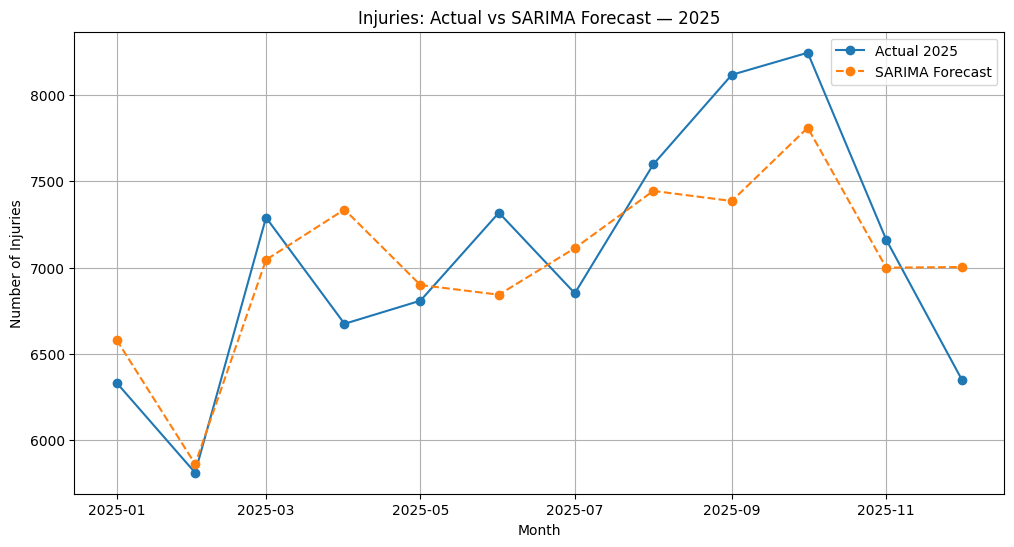

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison.index,
    comparison["Actual_Injuries"],
    marker="o",
    label="Actual 2025"
)

plt.plot(
    comparison.index,
    comparison["Forecast_Injuries"],
    marker="o",
    linestyle="--",
    label="SARIMA Forecast"
)

plt.title("Injuries: Actual vs SARIMA Forecast — 2025")
plt.xlabel("Month")
plt.ylabel("Number of Injuries")
plt.legend()
plt.grid(True)
plt.show()

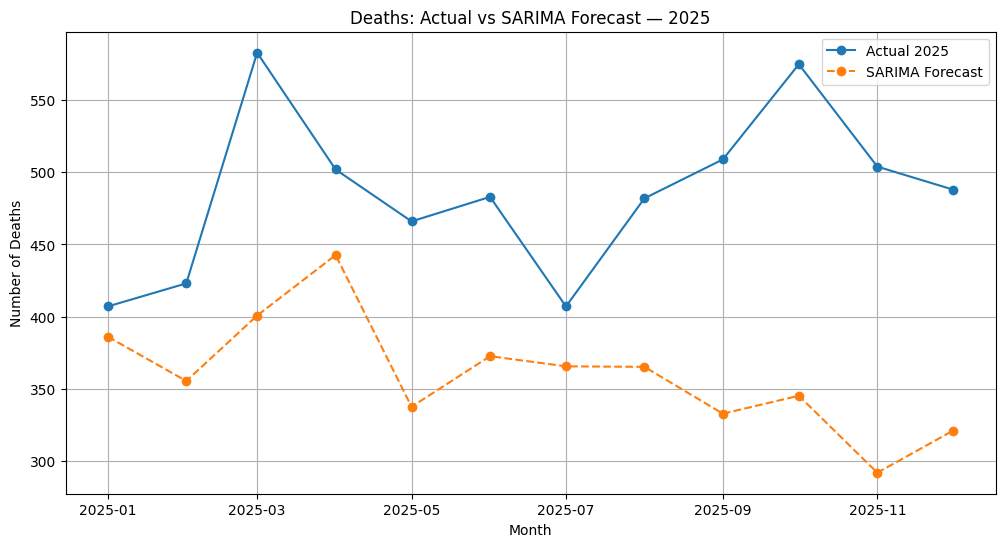

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison.index,
    comparison["Actual_Death"],
    marker="o",
    label="Actual 2025"
)

plt.plot(
    comparison.index,
    comparison["Forecast_Death"],
    marker="o",
    linestyle="--",
    label="SARIMA Forecast"
)

plt.title("Deaths: Actual vs SARIMA Forecast — 2025")
plt.xlabel("Month")
plt.ylabel("Number of Deaths")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Prepare data for Power BI

powerbi_data = comparison.reset_index()

powerbi_data = powerbi_data.rename(columns={
    "index": "Date"
})

# Save as CSV
powerbi_data.to_csv("sarima_powerbi.csv", index=False)

# Check the result
print(powerbi_data)
print("\nColumns:")
print(powerbi_data.columns)


         Date  Actual_Injuries  Forecast_Injuries  Actual_Death  \
0  2025-01-01             6332        6580.429881           407   
1  2025-02-01             5811        5861.092219           423   
2  2025-03-01             7290        7044.814714           583   
3  2025-04-01             6674        7336.283363           502   
4  2025-05-01             6808        6898.636755           466   
5  2025-06-01             7318        6842.669070           483   
6  2025-07-01             6851        7112.506706           407   
7  2025-08-01             7598        7444.203238           482   
8  2025-09-01             8117        7385.629910           509   
9  2025-10-01             8245        7810.402406           575   
10 2025-11-01             7162        6999.409006           504   
11 2025-12-01             6347        7003.100003           488   

    Forecast_Death  
0       386.033480  
1       355.280884  
2       400.667402  
3       442.627551  
4       337.416923  
5 